In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("govt_schemes.csv")
df.head()

,Scheme,Category,State,Year,Budget_Crore,Beneficiaries_Lakhs,Growth_Percent,Utilization_Percent,Impact_Score,Citizen_Satisfaction,Infrastructure_Score,Digital_Access_Percent,Budget_Per_Beneficiary,Efficiency_Score
0,PM Kisan Samman Nidhi,Agriculture,Karnataka,2022,6584.27,386.79,18.99,91.93,355.58,90.74,56.54,64.99,17.02,326.88
1,PM Kisan Samman Nidhi,Agriculture,Karnataka,2023,6986.74,35.43,7.16,78.05,27.65,80.70,41.46,92.47,197.20,21.58
2,PM Kisan Samman Nidhi,Agriculture,Karnataka,2024,9368.86,440.53,28.98,50.33,221.72,82.46,37.14,23.51,21.27,111.59
3,PM Kisan Samman Nidhi,Agriculture,Karnataka,2025,8782.95,71.86,76.59,64.59,46.41,64.98,63.38,57.54,122.22,29.98
4,PM Kisan Samman Nidhi,Agriculture,Karnataka,2026,5313.19,159.50,41.95,74.15,118.27,87.63,74.71,65.19,33.31,87.70


In [3]:
df.shape

(2325, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2325 entries, 0 to 2324
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Scheme                  2325 non-null   object 
 1   Category                2325 non-null   object 
 2   State                   2325 non-null   object 
 3   Year                    2325 non-null   int64  
 4   Budget_Crore            2325 non-null   float64
 5   Beneficiaries_Lakhs     2325 non-null   float64
 6   Growth_Percent          2325 non-null   float64
 7   Utilization_Percent     2325 non-null   float64
 8   Impact_Score            2325 non-null   float64
 9   Citizen_Satisfaction    2325 non-null   float64
 10  Infrastructure_Score    2325 non-null   float64
 11  Digital_Access_Percent  2325 non-null   float64
 12  Budget_Per_Beneficiary  2325 non-null   float64
 13  Efficiency_Score        2325 non-null   float64
dtypes: float64(10), int64(1), object(3)
memo

In [5]:
df['Category'].value_counts()

Category
Agriculture       450
Healthcare        375
Education         375
Employment        375
Social Welfare    375
Infrastructure    375
Name: count, dtype: int64

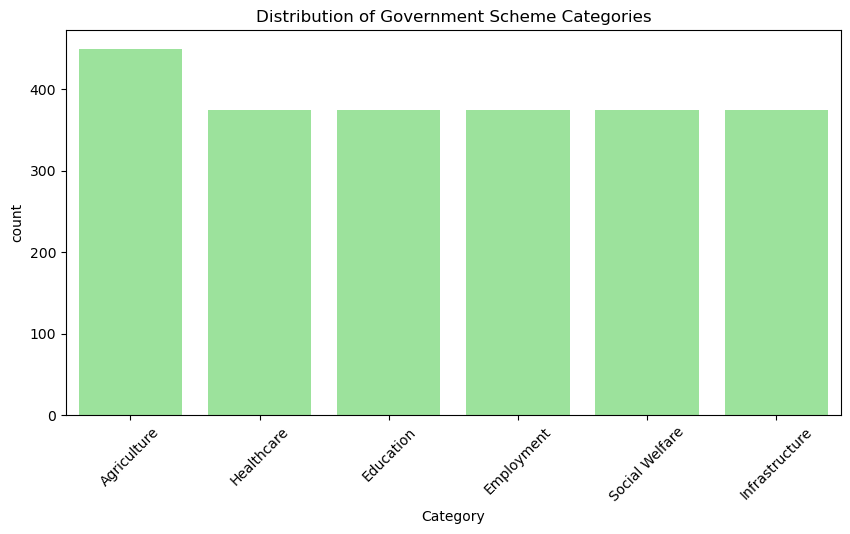

In [6]:
plt.figure(figsize=(10,5))
sns.countplot(x='Category', data=df, color='lightgreen')
plt.title("Distribution of Government Scheme Categories")
plt.xticks(rotation=45)
plt.show()

Text(0, 0.5, 'Frequency')

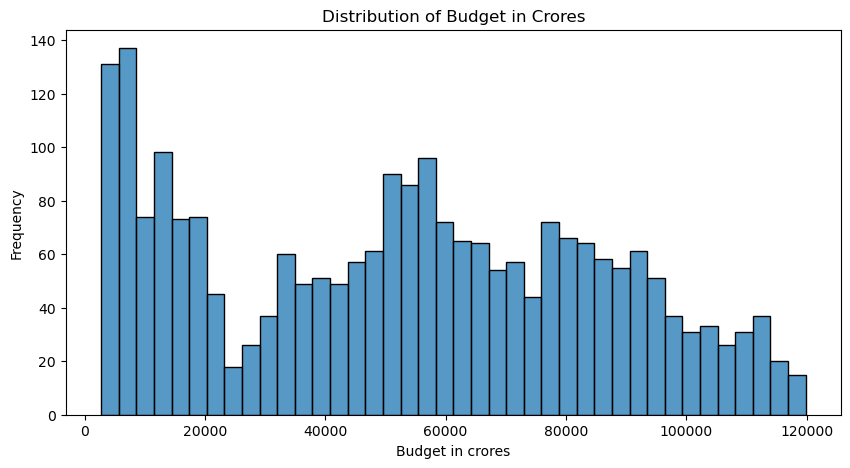

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(df['Budget_Crore'], bins=40)
plt.title("Distribution of Budget in Crores")
plt.xlabel("Budget in crores")
plt.ylabel("Frequency")

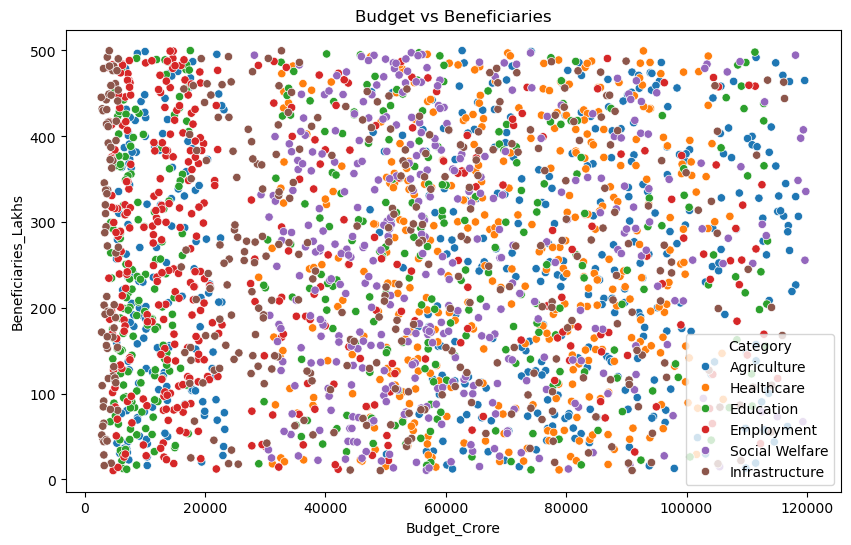

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Budget_Crore', y='Beneficiaries_Lakhs', hue='Category', data=df)
plt.title("Budget vs Beneficiaries")
plt.show()

Text(0.5, 1.0, 'Correaltion Heatmap')

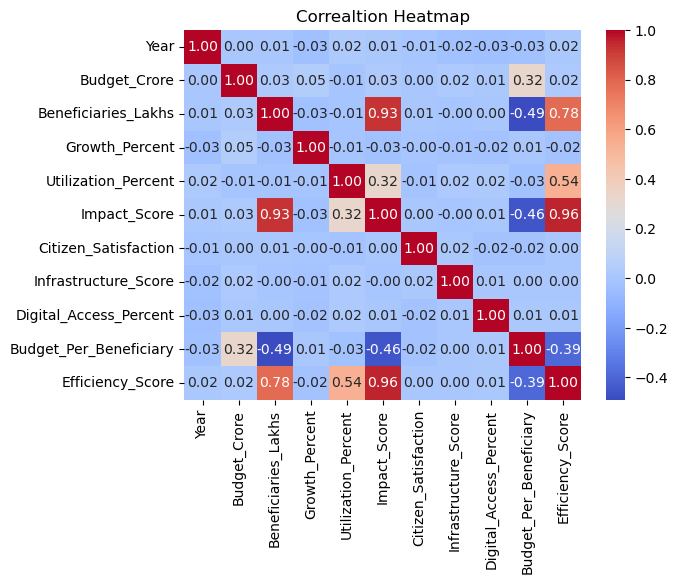

In [9]:
correlation=df.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap='coolwarm',fmt='.2f')
plt.title("Correaltion Heatmap")

In [10]:
avg_budget = df.groupby('Category')['Budget_Crore'].mean()
avg_budget

Category
Agriculture       60443.066867
Education         43211.792533
Employment        32903.953920
Healthcare        70084.930347
Infrastructure    46082.106400
Social Welfare    60997.431973
Name: Budget_Crore, dtype: float64

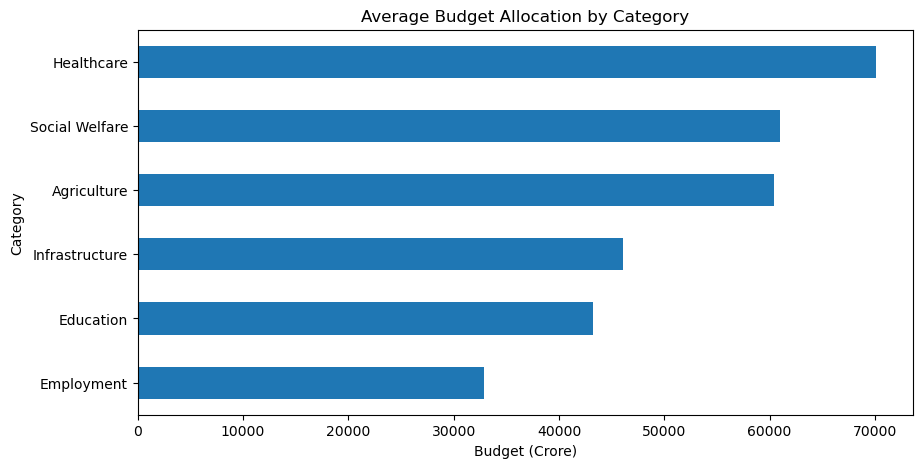

In [11]:
plt.figure(figsize=(10,5))
avg_budget.sort_values().plot(
    kind='barh'
)
plt.title("Average Budget Allocation by Category")
plt.xlabel("Budget (Crore)")
plt.show()

In [12]:
state_efficiency=df.groupby('State')['Efficiency_Score'].mean()
state_efficiency

State
Andhra Pradesh    144.751871
Assam             144.178000
Bihar             148.283935
Gujarat           154.014452
Karnataka         157.945097
Kerala            140.042516
Madhya Pradesh    158.182452
Maharashtra       150.229032
Odisha            150.742645
Punjab            150.139419
Rajasthan         142.045290
Tamil Nadu        141.854258
Telangana         142.731355
Uttar Pradesh     143.744903
West Bengal       146.348710
Name: Efficiency_Score, dtype: float64

In [13]:
top_states=state_efficiency.sort_values(ascending=False).head(10)

Text(0, 0.5, 'Efficiency score')

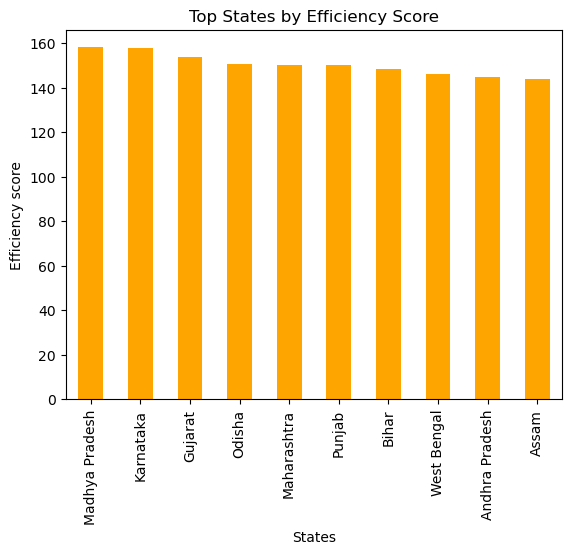

In [14]:
top_states.plot(kind='bar', color='orange')
plt.title("Top States by Efficiency Score")
plt.xlabel("States")
plt.ylabel("Efficiency score")

In [15]:
yearwise_budget=df.groupby('Year')['Budget_Crore'].sum()

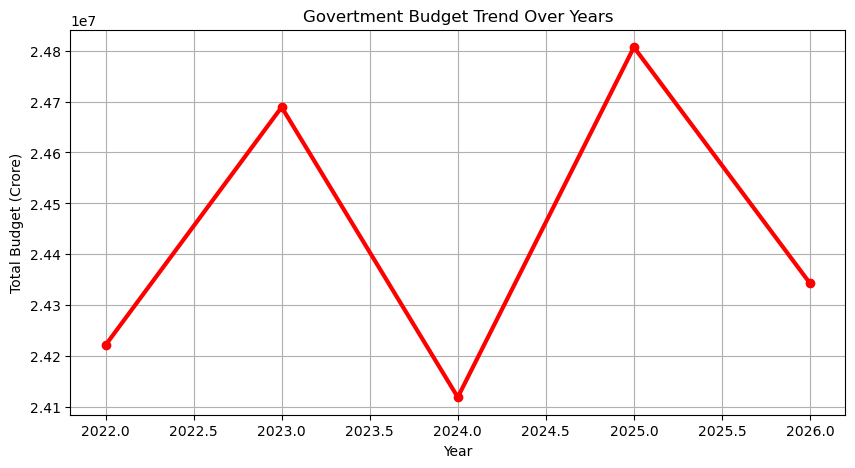

In [16]:
plt.figure(figsize=(10,5))
yearwise_budget.plot(marker='o', linewidth=3,color='red')
plt.title("Govertment Budget Trend Over Years")
plt.ylabel("Total Budget (Crore)")
plt.grid(True)

Text(0.5, 1.0, 'Budget DIstribution Across Categories')

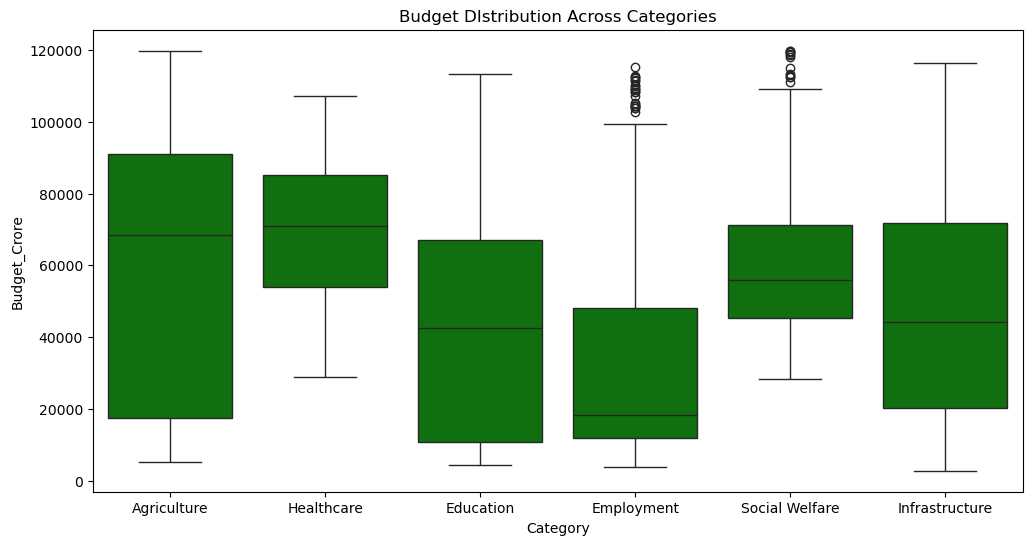

In [17]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Category', y='Budget_Crore', data=df, color='green')
plt.title("Budget DIstribution Across Categories")

In [18]:
top_schemes=df.groupby('Scheme')['Budget_Crore'].mean().sort_values(ascending=False).head(10)

Text(0.5, 0, 'Avg Budget (Crore)')

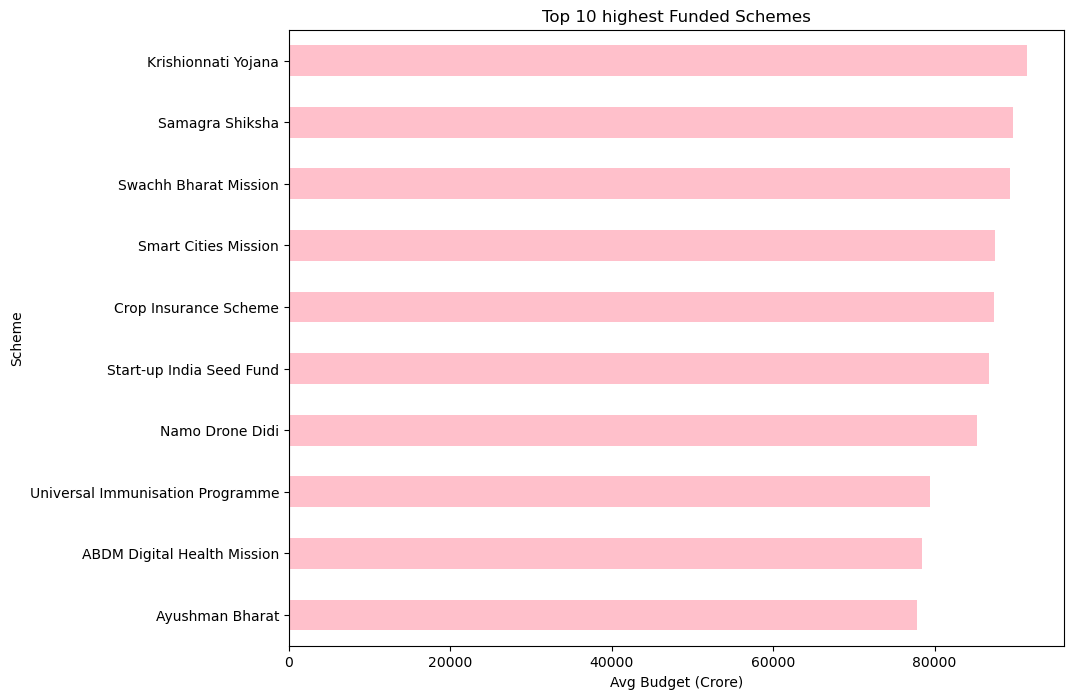

In [32]:
plt.figure(figsize = (10,8))
top_schemes.sort_values().plot(kind='barh', color='pink')
plt.title("Top 10 highest Funded Schemes")
plt.xlabel("Avg Budget (Crore)")

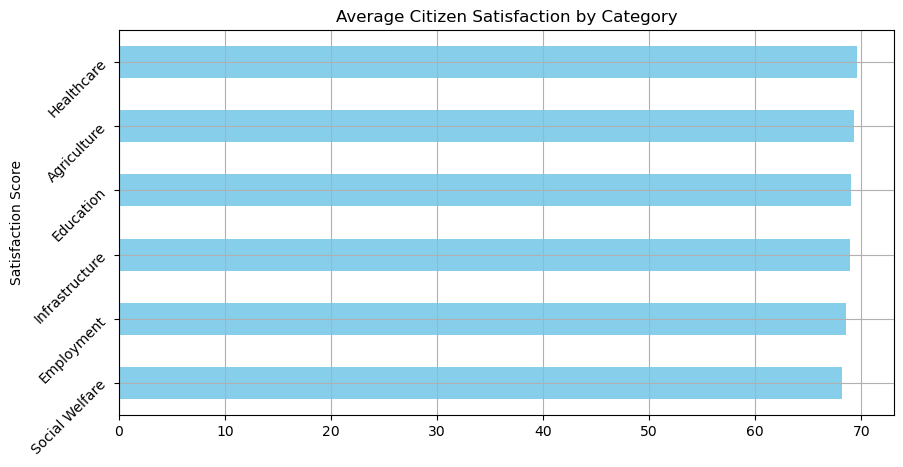

In [43]:
avg_satisfaction = df.groupby('Category')['Citizen_Satisfaction'].mean()
plt.figure(figsize=(10,5))
avg_satisfaction.sort_values().plot(kind='barh', color='skyblue')
plt.title("Average Citizen Satisfaction by Category")
plt.ylabel("Satisfaction Score")
plt.yticks(rotation=45)
plt.grid(True)
plt.show()

Text(0, 0.5, 'DIgital Access %')

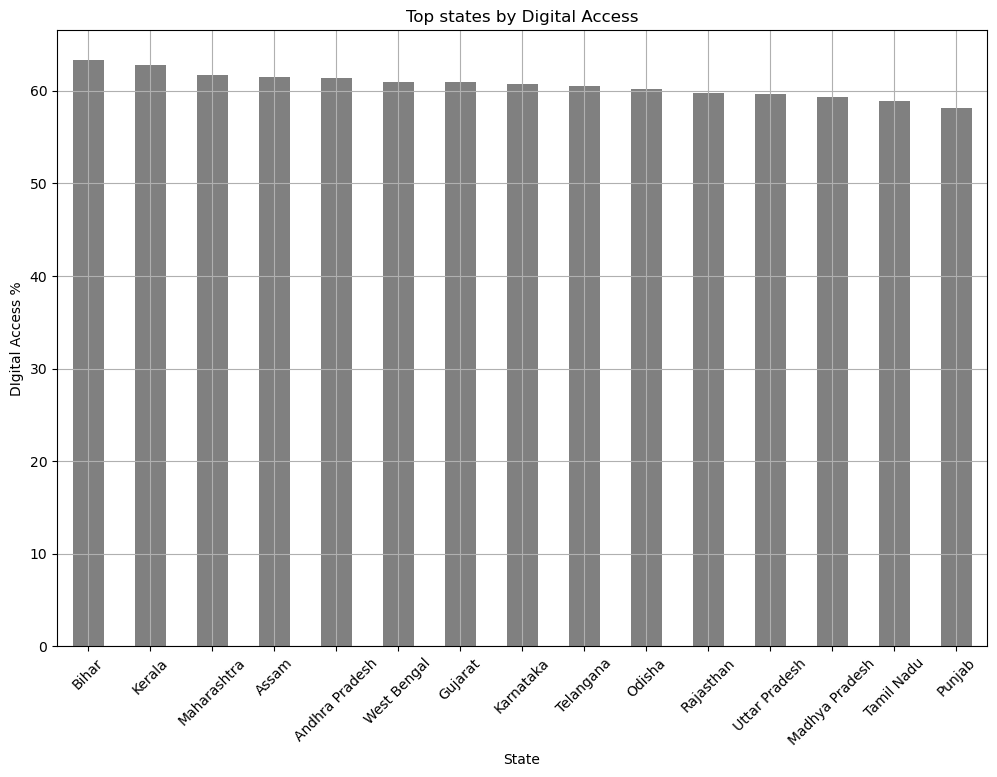

In [58]:
digital_access = df.groupby('State')['Digital_Access_Percent'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,8))
digital_access.head(15).plot(kind='bar', color='grey')
plt.title("Top states by Digital Access")
plt.xticks(rotation=45)
plt.grid(True)
plt.ylabel("DIgital Access %")

Text(0.5, 1.0, 'Fund Utilization Distribution')

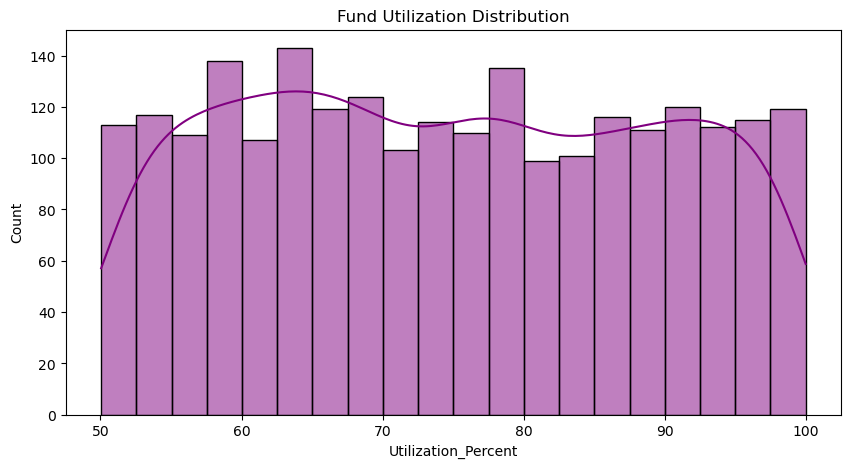

In [60]:
plt.figure(figsize=(10,5))
sns.histplot(df['Utilization_Percent'],bins=20,kde=True,color='purple')
plt.title("Fund Utilization Distribution")

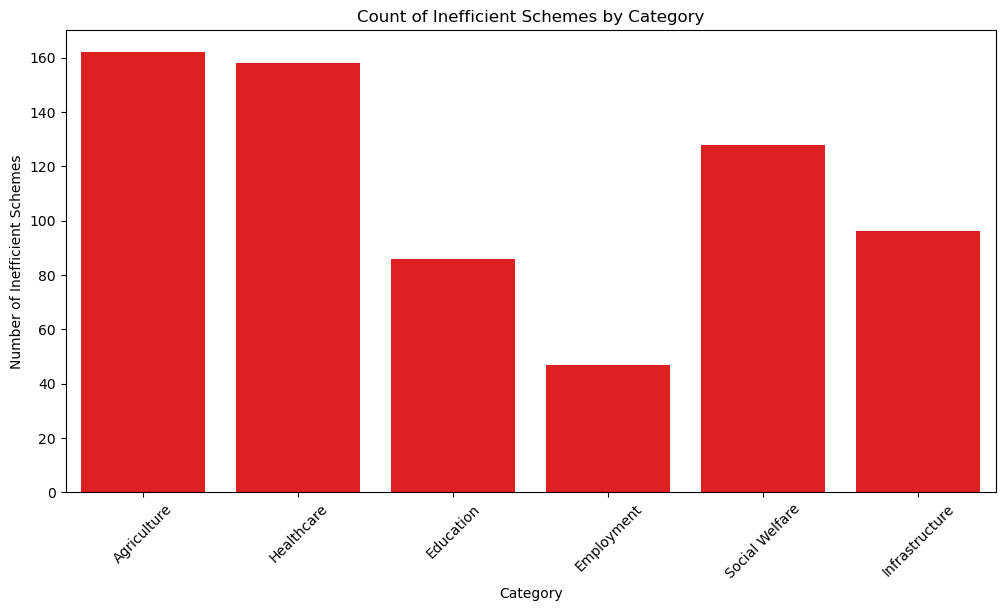

In [106]:
inefficient = df[
    (df['Budget_Crore'] > df['Budget_Crore'].mean()) &
    (df['Efficiency_Score'] < df['Efficiency_Score'].mean())]
plt.figure(figsize=(12,6))
sns.countplot(x='Category', data=inefficient, color='red')
plt.xticks(rotation=45)
plt.title("Count of Inefficient Schemes by Category")
plt.xlabel("Category")
plt.ylabel("Number of Inefficient Schemes")
plt.show()

In [112]:
total_budget = df['Budget_Crore'].sum()
print(f"Total Budget Allocation:{total_budget:.2f} Crore")
total_beneficiaries = df['Beneficiaries_Lakhs'].sum()
print(f"Total Beneficiaries:{total_beneficiaries:.2f}")
avg_efficiency = df['Efficiency_Score'].mean()
print(f"Average Efficiency:{avg_efficiency:.2f}")
avg_satisfaction = df['Citizen_Satisfaction'].mean()
print(f"Average Satisfaction:{avg_satisfaction:.2f}")

Total Budget Allocation:122179460.78 Crore
Total Beneficiaries:592843.97
Average Efficiency:147.68
Average Satisfaction:68.93
